Out-of-Sample Forecast Metrics:
     Asset      MSE        R²  Directional Accuracy  Spearman
es1_logret 0.000670 -0.060086              0.160256 -0.030562
vg1_logret 0.000948 -0.114854              0.176282 -0.005737
 z1_logret 0.000689 -0.073621              0.160256 -0.008721
rx1_logret 0.000116 -0.023761              0.208333  0.053346
gc1_logret 0.000451 -0.032555              0.163462 -0.028351
co1_logret 0.004003 -0.144623              0.394231  0.038517
hg1_logret 0.000984 -0.010830              0.163462 -0.006455

In-Sample Forecast Metrics:
     Asset      MSE        R²  Directional Accuracy  Spearman
es1_logret 0.000298  0.015109              0.560000  0.092888
vg1_logret 0.000548 -0.000470              0.010000       NaN
 z1_logret 0.000457  0.015941              0.496667  0.132912
rx1_logret 0.000054 -0.002818              0.003333       NaN
gc1_logret 0.000415  0.032152              0.520000  0.154747
co1_logret 0.001700  0.014707              0.500000  0.103651
hg1_logre

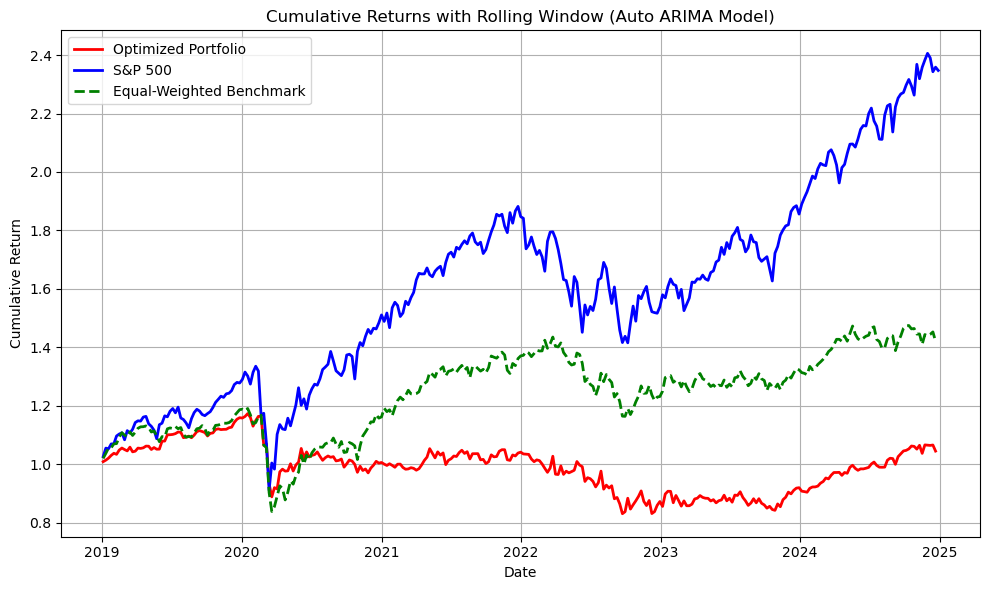

In [35]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from pmdarima import auto_arima
import warnings
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
np.random.seed(42)

start_time = time.time()

###############################################################################
# 1. Define CVaR Computation and Objective Function
###############################################################################
def compute_cvar(historical_returns, weights, alpha=0.9):
    port_returns = np.dot(historical_returns, weights)
    sorted_returns = np.sort(port_returns)
    cutoff = int(np.floor((1 - alpha) * len(sorted_returns)))
    cutoff = max(cutoff, 0)
    worst_returns = sorted_returns[:cutoff+1]
    cvar = np.mean(worst_returns) if len(worst_returns) > 0 else sorted_returns[cutoff]
    return cvar

def cvar_objective(weights, predicted_returns, historical_returns, alpha=0.9, lambda_reg=0.01):
    eps = 1e-8
    port_return = np.dot(weights, predicted_returns)
    port_cvar = compute_cvar(historical_returns, weights, alpha=alpha)
    return -port_return / (abs(port_cvar) + eps) + lambda_reg * np.sum(weights**2)

###############################################################################
# 2. Load Data and Create Initial Training and Test Sets
###############################################################################
price_data = pd.read_excel(
    r'C:\Users\orekh\Desktop\MMF\Thesis\Data\broader_weekly_data_filled.xlsx',
    parse_dates=["date"],
    index_col="date"
)
filtered_returns = price_data.iloc[:, :7]

train_start_date = '2013-04-01'
train_end_date   = '2018-12-31'
test_start_date  = '2019-01-01'
test_end_date    = '2025-01-01'

train_returns_all = filtered_returns.loc[train_start_date:train_end_date]
test_returns = filtered_returns.loc[test_start_date:test_end_date]

###############################################################################
# 3. Rolling Window Forecasting, Model Updates & Portfolio Optimization
###############################################################################
rolling_window_size = 78        
test_window_size = 12           
model_update_frequency_windows = 2  
rebalance_frequency = 2             

training_window = train_returns_all.iloc[-rolling_window_size:].copy()
all_forecasts = pd.DataFrame(index=test_returns.index, columns=test_returns.columns)
optimized_portfolio_returns = []
benchmark_returns = []
current_models = {}
n_assets = training_window.shape[1]
prev_weights = np.ones(n_assets) / n_assets

n_test = len(test_returns)
n_windows = int(np.floor(n_test / test_window_size))
test_dates = test_returns.index

for window_idx in range(n_windows):
    start_idx = window_idx * test_window_size
    end_idx = start_idx + test_window_size
    window_dates = test_dates[start_idx:end_idx]
    test_window = test_returns.loc[window_dates]

    if window_idx % model_update_frequency_windows == 0:
        for asset in training_window.columns:
            model = auto_arima(
                training_window[asset],
                seasonal=False,
                error_action='ignore',
                suppress_warnings=True,
                stepwise=True
            )
            current_models[asset] = model

    forecasts_window = pd.DataFrame(index=window_dates, columns=test_window.columns)
    for date in window_dates:
        forecast_values = {}
        for asset in test_window.columns:
            model = current_models[asset]
            forecast = model.predict(n_periods=1)[0]
            forecast_values[asset] = forecast
            obs = test_window.loc[date, asset]
            model.update(obs)
        forecasts_window.loc[date] = pd.Series(forecast_values)
    all_forecasts.loc[window_dates] = forecasts_window

    expected_returns = forecasts_window.iloc[0].fillna(0).values
    historical_returns = training_window.values

    if window_idx % rebalance_frequency == 0:
        init_guess = np.ones(n_assets) / n_assets
        bounds = [(0, 1)] * n_assets
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: 0.4 - np.max(w)},
            {'type': 'ineq', 'fun': lambda w: np.min(w) - 0.0}
        ]
        res = minimize(
            cvar_objective,
            init_guess,
            args=(expected_returns, historical_returns, 0.95, 0.01),
            method='SLSQP',
            bounds=bounds,
            constraints=constraints
        )
        weights = res.x if res.success else init_guess
    else:
        weights = prev_weights.copy()

    for date in window_dates:
        realized_return = test_window.loc[date].values
        turnover = np.sum(np.abs(weights - prev_weights))
        cost = 0.0001 * turnover
        port_return = np.dot(weights, realized_return)
        net_return = port_return - cost
        optimized_portfolio_returns.append(net_return)
        benchmark_returns.append(np.dot(np.ones(n_assets)/n_assets, realized_return))
    prev_weights = weights.copy()
    training_window = pd.concat([training_window, test_window]).iloc[-rolling_window_size:].copy()

###############################################################################
# 4. Compute Portfolio Performance Metrics
###############################################################################
optimized_cumulative_returns = (1 + np.array(optimized_portfolio_returns)).cumprod()
benchmark_cumulative_returns = (1 + np.array(benchmark_returns)).cumprod()

def calculate_sharpe_ratio(returns, risk_free_rate=0):
    excess = np.array(returns) - risk_free_rate
    return np.mean(excess) / (np.std(excess, ddof=1) + 1e-9)

def calculate_max_drawdown(cum_returns):
    cum_max = np.maximum.accumulate(cum_returns)
    drawdown = (cum_max - cum_returns) / cum_max
    return np.max(drawdown)

sharpe_optimized = calculate_sharpe_ratio(optimized_portfolio_returns)
sharpe_benchmark = calculate_sharpe_ratio(benchmark_returns)

annual_factor = np.sqrt(52)  # Annualize weekly data
ann_sharpe_optimized = sharpe_optimized * annual_factor
ann_sharpe_benchmark = sharpe_benchmark * annual_factor

max_drawdown_optimized = calculate_max_drawdown(optimized_cumulative_returns)
max_drawdown_benchmark = calculate_max_drawdown(benchmark_cumulative_returns)

final_cum_optimized = optimized_cumulative_returns[-1]
final_cum_benchmark = benchmark_cumulative_returns[-1]

###############################################################################
# 5. Compute S&P 500 Metrics
###############################################################################
sp_data = pd.read_excel(
    r'C:\Users\orekh\Desktop\MMF\Thesis\Data\s_p_ret.xlsx',
    parse_dates=["date"],
    index_col="date"
)
sp_returns = sp_data['sp_ret']
sp_returns = sp_returns.loc[test_start_date:test_end_date]
sp_cumulative_returns = (1 + sp_returns).cumprod()
sharpe_sp = calculate_sharpe_ratio(sp_returns.dropna())
ann_sharpe_sp = sharpe_sp * annual_factor
final_cum_sp = sp_cumulative_returns.iloc[-1]

###############################################################################
# 6. Compute Forecast Metrics Tables (In-Sample & Out-of-Sample)
###############################################################################
# Out-of-Sample metrics
metrics_data_out = []
for asset in test_returns.columns:
    # Align forecast and actual series by index
    forecast_series = all_forecasts[asset].dropna()
    actual_series = test_returns.loc[forecast_series.index, asset]
    mse = mean_squared_error(actual_series.values.astype(float), forecast_series.values.astype(float))
    r2 = r2_score(actual_series.values.astype(float), forecast_series.values.astype(float))
    directional_accuracy = np.mean(np.sign(actual_series) == np.sign(forecast_series))
    sp_corr = spearmanr(actual_series, forecast_series)[0]
    metrics_data_out.append({
         "Asset": asset,
         "MSE": mse,
         "R²": r2,
         "Directional Accuracy": directional_accuracy,
         "Spearman": sp_corr
    })
metrics_df_out = pd.DataFrame(metrics_data_out)

# In-Sample metrics (using training data)
metrics_data_in = []
for asset in train_returns_all.columns:
    model = auto_arima(
        train_returns_all[asset],
        seasonal=False,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )
    fitted = model.predict_in_sample()
    actual = train_returns_all[asset].values.astype(float)
    mse = mean_squared_error(actual, fitted)
    r2 = r2_score(actual, fitted)
    directional_accuracy = np.mean(np.sign(actual) == np.sign(fitted))
    sp_corr = spearmanr(actual, fitted)[0]
    metrics_data_in.append({
         "Asset": asset,
         "MSE": mse,
         "R²": r2,
         "Directional Accuracy": directional_accuracy,
         "Spearman": sp_corr
    })
metrics_df_in = pd.DataFrame(metrics_data_in)

print("Out-of-Sample Forecast Metrics:")
print(metrics_df_out.to_string(index=False))
print("\nIn-Sample Forecast Metrics:")
print(metrics_df_in.to_string(index=False))

###############################################################################
# 7. Print Portfolio and Benchmark Performance Metrics
###############################################################################
print("\nPerformance Metrics:")
print(f"Optimized Portfolio - Annualized Sharpe: {ann_sharpe_optimized:.2f}, Max Drawdown: {max_drawdown_optimized:.2%}, Final Cumulative Return: {final_cum_optimized:.2f}")
print(f"Benchmark Portfolio - Annualized Sharpe: {ann_sharpe_benchmark:.2f}, Max Drawdown: {max_drawdown_benchmark:.2%}, Final Cumulative Return: {final_cum_benchmark:.2f}")
print(f"S&P 500 - Annualized Sharpe: {ann_sharpe_sp:.2f}, Final Cumulative Return: {final_cum_sp:.2f}")

end_time = time.time()
print("\nProcessing time: {:.0f} min".format((end_time - start_time) / 60))

###############################################################################
# 8. Plot Cumulative Returns
###############################################################################
plt.figure(figsize=(10, 6))
plt.plot(test_returns.index[:len(optimized_cumulative_returns)], optimized_cumulative_returns, 
         label='Optimized Portfolio', color='red', linewidth=2)
plt.plot(test_returns.index[:len(sp_cumulative_returns)], sp_cumulative_returns, 
         label='S&P 500', color='blue', linewidth=2)
plt.plot(test_returns.index[:len(benchmark_cumulative_returns)], benchmark_cumulative_returns, 
         label='Equal-Weighted', color='green', linestyle='--', linewidth=2)
plt.title('Cumulative Returns with Rolling Window (ARIMA)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
